In [13]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
import glob #for path/to/folder
import random
import math

#for extracting hand landmarks
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from collections import Counter

#for the SVM
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

#for the CNN
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader


In [14]:
#installing mediapipe - note that Python version 3.13+ doesn't support mediapipe for some reason
#!pip install -q mediapipe

#using a model that is ready-made to extract hand points from an image
#for windows: 
#!wget -q https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task 

#for mac:
!curl -O https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 7635k  100 7635k    0     0  13.9M      0 --:--:-- --:--:-- --:--:-- 13.9M


In [15]:
#getting the drawing utils
mp_drawing = mp.solutions.drawing_utils

#setting up the hand landmark detection model:
base_options = python.BaseOptions(
    model_asset_path='hand_landmarker.task', 
    delegate=python.BaseOptions.Delegate.CPU
    )
options = vision.HandLandmarkerOptions(
    base_options=base_options, 
    running_mode=vision.RunningMode.IMAGE, 
    num_hands=1, #dataset only shows 1 hand for each sign
    min_hand_detection_confidence=0.1,
    min_tracking_confidence=0.2
    )
detector = vision.HandLandmarker.create_from_options(options=options)


I0000 00:00:1777921028.121872 29462934 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M1
W0000 00:00:1777921028.177333 29474225 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777921028.187110 29474223 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [120]:
#storing dataset and labels:
hand_landmark_data = []
hand_landmark_label = []

#directories of dataset
#img_dir = 'asl_dataset'
#sub_dirs = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y'] #only looking at these characters 
img_dir = 'ASLDataset/Train'
sub_dirs = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']
for dir in sub_dirs:
    path = f'{img_dir}/{dir}'
    #print(path)
    data_path = os.path.join(f'{img_dir}/{dir}',"*.jpg") # *.jpg is to only read files of .jpg
    files = glob.glob(data_path) 
    count_files = 0 #just to help find all the images of each letter in dataset
    for f1 in files:
        count_files += 1
        img = cv2.imread(f1) 
        #make sure img is read and exists
        if img is None:
            print("failed to load ", f1)
            continue
            
        #change bgr to rgb
        RGB_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        #turn into mediapipe image before extracting landmarks (if possible)
        #test = cv2.resize(RGB_img, (640, 480))
        test = np.ascontiguousarray(RGB_img)
        image = mp.Image(
            image_format=mp.ImageFormat.SRGB, 
            data=test
        )
        result = detector.detect(image) #gets all hand landmarks 
                                        #in the image for each hand detected
        if not result.hand_landmarks:
            continue
        else:
            hand = result.hand_landmarks[0]
            coords = []
            #flipped_coords = []
            palmX, palmY, palmZ = hand[0].x, hand[0].y, hand[0].z
            for landmark in hand:
                coords.extend([landmark.x-palmX, landmark.y-palmY, landmark.z-palmZ])
                #flipped_coords.extend([1.0-(landmark.x-palmX), landmark.y-palmY, landmark.z-palmZ])
            hand_landmark_data.append(coords)
            hand_landmark_label.append(dir)
            #tried to work this, but it failed - store the "negative" version of the coords to account for left-hand dominant people
            #hand_landmark_data.append(flipped_coords)
            #hand_landmark_label.append(f'{dir}_flipped')
        if count_files == 200: break
print("dataset has been processed")

dataset has been processed


In [121]:
print(hand_landmark_data[0])
print(len(hand_landmark_data[0]))
print(hand_landmark_data[1])
print(len(hand_landmark_data[1]))
print(len(hand_landmark_data))

[0.0, 0.0, 0.0, -0.1287596970796585, -0.05322521924972534, -0.04634119744571308, -0.23208920657634735, -0.1710357666015625, -0.06384583364399532, -0.2644287496805191, -0.2947768568992615, -0.0832027400580273, -0.24513521045446396, -0.3831586241722107, -0.08674292068155864, -0.17221197485923767, -0.3162246644496918, 0.016077384472168887, -0.1912735551595688, -0.4094533622264862, -0.04431550006540874, -0.18185319006443024, -0.30260026454925537, -0.07104816834601024, -0.16517527401447296, -0.2665529251098633, -0.07936785171898464, -0.09737610816955566, -0.3206077814102173, 0.014948053404964412, -0.1120239645242691, -0.4059394299983978, -0.044813288256250416, -0.1116202175617218, -0.2829021215438843, -0.04812249343069652, -0.09762156009674072, -0.26188206672668457, -0.03275055612596134, -0.01991325616836548, -0.3114594519138336, -0.0012803634132296793, -0.029770195484161377, -0.3993067741394043, -0.06503391067656139, -0.03895211219787598, -0.2799417972564697, -0.03705369482906917, -0.02714

### Setting up Data for Training

We want to reserve some of the dataset for training and validation (60% and 10% respectively), and then the rest for testing (30%).

In [122]:
#need to encode the labels as numerical values before setting up datasets:
le = LabelEncoder()
y_encoded = le.fit_transform(hand_landmark_label)

In [123]:
#setting up test dataset and training datasets
#X_train: X_train instead of x_train here to note that we're splitting further to training and validation sets
X_train, x_test, Y_train, y_test = train_test_split(
    hand_landmark_data, 
    y_encoded,
    test_size=0.3,
    random_state=42,
    stratify=y_encoded
)

#X_train and y_train has 70%
#X_train and y_train = around 85% of 70% (60%/70%)
#X_val and y_val = around 15% of 70%
x_train, x_val, y_train, y_val = train_test_split(
    X_train, 
    Y_train,
    test_size= (10/70),
    random_state=42,
    stratify=Y_train
)

In [124]:
#setting up tensors (for CNN)
x_train = np.array(x_train).reshape(-1, 21, 3)
y_train = np.array(y_train)
x_val = np.array(x_val).reshape(-1, 21, 3)
y_val = np.array(y_val)
x_test = np.array(x_test).reshape(-1, 21, 3)
y_test = np.array(y_test)

x_train_tensor = torch.tensor(data=x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(data=y_train, dtype=torch.long)
x_val_tensor = torch.tensor(data=x_val, dtype=torch.float32)
y_val_tensor = torch.tensor(data=y_val, dtype=torch.long)
x_test_tensor = torch.tensor(data=x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(data=y_test, dtype=torch.long)


In [125]:
class CNNModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.conv1 = nn.Conv1d(in_channels=3, out_channels=32, kernel_size=3)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=128, kernel_size=3)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2)

        self.fc1 = nn.Linear(in_features=128 * 3, out_features=128)
        self.fc2 = nn.Linear(in_features=128, out_features=num_classes)


    def forward(self, x):
        #in the beginning, our input tensor (x) is of the form (batch, 21 landmarks per hand, and 3 coord points xyz). 
        #we want to reshape it to (batch, 3, 21)
        x = x.permute(0, 2, 1)

        x = self.pool(self.relu(self.conv1(x)))  #shaping data for conv1 -> conv2

        x = self.pool(self.relu(self.conv2(x))) #shaping data for conv2 -> pool

        #print(x.shape) #only to help with finding in_features for fc1

        x = x.view(x.size(0), -1) #reshaping data from pool to fc1

        x = self.relu(self.fc1(x)) #shaping data for fc1 -> fc2
        
        x = self.fc2(x) #output logits (scores of each letter class)

        return x

In [126]:
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
validation_dataset = TensorDataset(x_val_tensor, y_val_tensor)
validation_loader = DataLoader(validation_dataset, batch_size=64, shuffle=True)

#train and validate dataset with CNN
device= torch.device("cuda" if torch.cuda.is_available() else "cpu") #runs model on cuda (works fast) or cpu (depends on your device)
torch.manual_seed(0); np.random.seed(0); random.seed(0)
num_letters = len(set(y_train_tensor.tolist()))
cnn = CNNModel(num_classes=num_letters)
cnn.to(device)

total_epochs = 100
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(params=cnn.parameters(), lr=0.001)

#early stopping parameters
best_loss = float('inf')
best_validation_acc = float('-inf')
epochs_not_improving = 0

#storing accuracies and losses at each epoch for plotting
validation_losses = []
validation_accuracies = []
train_losses = []

for epoch in range(total_epochs):
    cnn.train()

    total_loss = 0.0
    for batch_sequences, batch_labels in train_loader:
        batch_sequences = batch_sequences.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()
        output = cnn(batch_sequences)
        loss = loss_function(output, batch_labels)
        loss.backward()
        nn.utils.clip_grad_norm_(cnn.parameters(), 1.0) #gradient clipping to avoid exploding gradients
        optimizer.step()

        total_loss += loss.item()
    train_loss = total_loss / len(train_loader)

    #validating
    cnn.eval()
    validation_loss = 0.0
    preds = []
    labels = []
    with torch.no_grad():
        for batch_sequences, batch_labels in validation_loader:
            batch_sequences = batch_sequences.to(device)
            batch_labels = batch_labels.to(device)
            output = cnn(batch_sequences)
            loss = loss_function(output, batch_labels)
            validation_loss += loss.item()
            preds.extend(torch.argmax(output, dim=1).cpu().numpy())
            labels.extend(batch_labels.cpu().numpy())
    validation_loss /= len(validation_loader)
    validation_accuracy = accuracy_score(labels, preds)

    print(f"Epoch {epoch+1}/{total_epochs} : Loss {train_loss} | Validation Loss: {validation_loss} | Validation Accuracy {validation_accuracy * 100:.4f}%")
    validation_accuracies.append(validation_accuracy)
    validation_losses.append(validation_loss)
    train_losses.append(train_loss)

    #store the model with the best validation accuracy - could be best model
    if validation_accuracy > best_validation_acc:
        best_validation_acc = validation_accuracy
        print("Storing best validation accuracy")
        torch.save(cnn.state_dict(), 'model_new_acc.pth')

    #either do early stopping or update to more optimal model
    if validation_loss < best_loss:
        best_loss = validation_loss
        print("Storing best validation loss")
        torch.save(cnn.state_dict(), 'model_new.pth')
        epochs_not_improving = 0
    else:
        epochs_not_improving += 1
        if epochs_not_improving >= 7:
            print("Early stopping!")
            break


Epoch 1/100 : Loss 2.822092225816515 | Validation Loss: 2.260502427816391 | Validation Accuracy 31.0127%
Storing best validation accuracy
Storing best validation loss
Epoch 2/100 : Loss 1.8747628000047472 | Validation Loss: 1.5280976295471191 | Validation Accuracy 50.6329%
Storing best validation accuracy
Storing best validation loss
Epoch 3/100 : Loss 1.3247815913624235 | Validation Loss: 1.1501511260867119 | Validation Accuracy 68.7764%
Storing best validation accuracy
Storing best validation loss
Epoch 4/100 : Loss 0.9916091097725762 | Validation Loss: 0.902137503027916 | Validation Accuracy 71.7300%
Storing best validation accuracy
Storing best validation loss
Epoch 5/100 : Loss 0.7588580621613397 | Validation Loss: 0.6604577675461769 | Validation Accuracy 79.3249%
Storing best validation accuracy
Storing best validation loss
Epoch 6/100 : Loss 0.6230859186914232 | Validation Loss: 0.5576791912317276 | Validation Accuracy 81.2236%
Storing best validation accuracy
Storing best valid

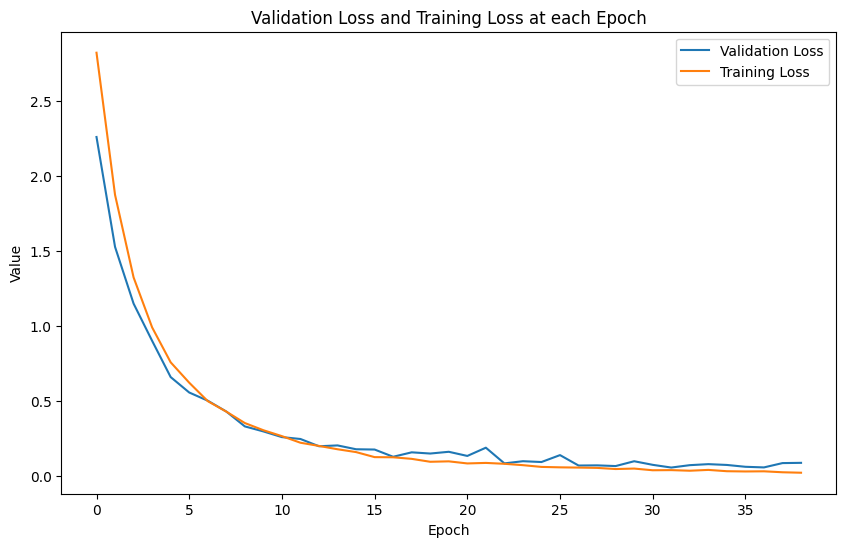

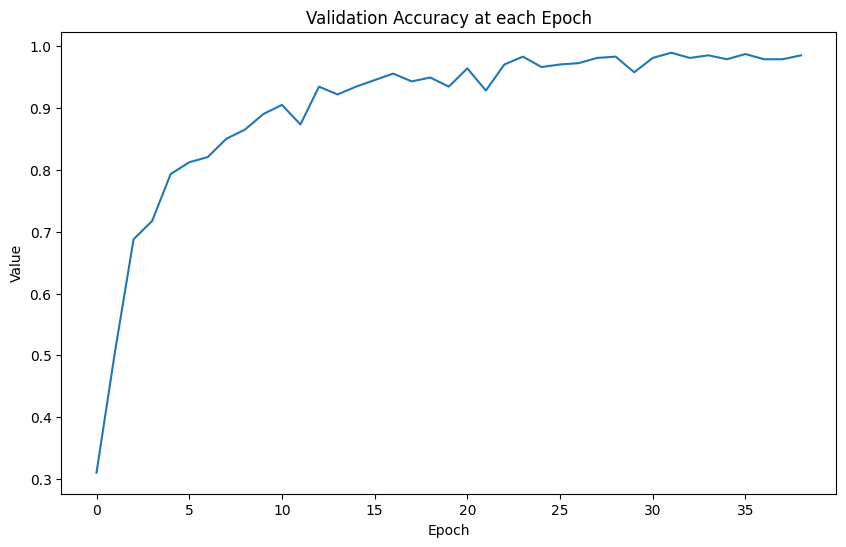

In [127]:
#plotting validation accuracies, validation losses, and training losses at each epoch
plt.figure(figsize=(10,6))
plt.plot(validation_losses, label='Validation Loss')
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Validation Loss and Training Loss at each Epoch')
plt.legend()
plt.show()

plt.figure(figsize=(10,6))
plt.plot(validation_accuracies, label='Validation Accuracy')
plt.title('Validation Accuracy at each Epoch')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.show()

Test Accuracy with model.pth: 99.2254%
              precision    recall  f1-score   support

           0     0.9833    0.9833    0.9833        60
           1     1.0000    1.0000    1.0000        60
           2     1.0000    1.0000    1.0000        60
           3     1.0000    1.0000    1.0000        60
           4     1.0000    1.0000    1.0000        60
           5     1.0000    1.0000    1.0000        60
           6     1.0000    1.0000    1.0000        60
           7     1.0000    1.0000    1.0000        60
           8     1.0000    0.9000    0.9474        60
           9     1.0000    1.0000    1.0000        60
          10     1.0000    1.0000    1.0000        60
          11     0.9672    1.0000    0.9833        59
          12     1.0000    0.9434    0.9709        53
          13     1.0000    1.0000    1.0000        58
          14     0.9811    1.0000    0.9905        52
          15     1.0000    1.0000    1.0000        58
          16     1.0000    1.0000    1.000

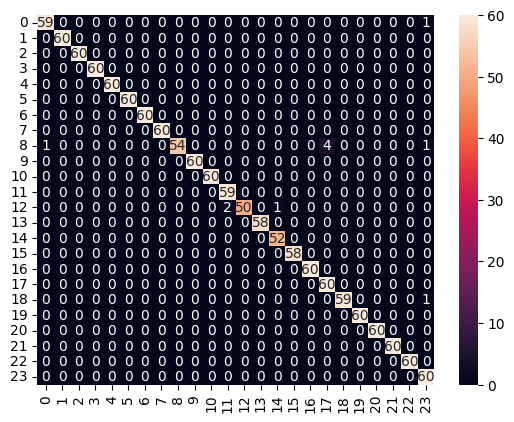

Test Accuracy with model_acc.pth: 99.2254%
              precision    recall  f1-score   support

           0     0.9833    0.9833    0.9833        60
           1     1.0000    1.0000    1.0000        60
           2     1.0000    1.0000    1.0000        60
           3     1.0000    1.0000    1.0000        60
           4     1.0000    1.0000    1.0000        60
           5     1.0000    1.0000    1.0000        60
           6     1.0000    1.0000    1.0000        60
           7     1.0000    1.0000    1.0000        60
           8     1.0000    0.9000    0.9474        60
           9     1.0000    1.0000    1.0000        60
          10     1.0000    1.0000    1.0000        60
          11     0.9672    1.0000    0.9833        59
          12     1.0000    0.9434    0.9709        53
          13     1.0000    1.0000    1.0000        58
          14     0.9811    1.0000    0.9905        52
          15     1.0000    1.0000    1.0000        58
          16     1.0000    1.0000    1

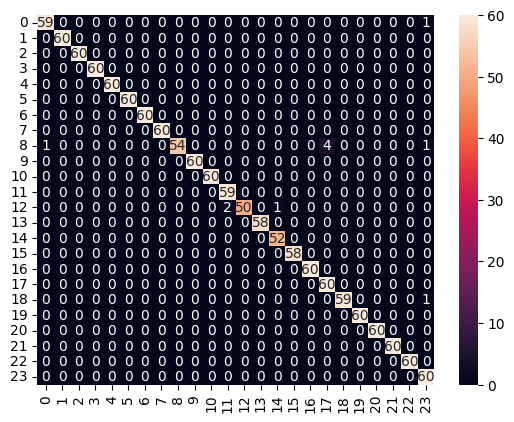

Best Test Accuracy: 99.2254%


In [128]:
#testing the model
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)

#load model.pth (best validation loss) from training loop
cnn.load_state_dict(torch.load('model_new.pth'))
cnn.to(device)
cnn.eval()
preds = []
labels = []
with torch.no_grad():
  for batch_sequences, batch_labels in test_loader:
    batch_sequences = batch_sequences.to(device)

    logits = cnn(batch_sequences)

    preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
    labels.extend(batch_labels.cpu().numpy())

test_accuracy_val_loss = accuracy_score(labels, preds)
print(f"Test Accuracy with model.pth: {test_accuracy_val_loss * 100:.4f}%")
print(classification_report(labels, preds, digits=4))
confusion_matrix_acc = confusion_matrix(labels, preds)
sns.heatmap(confusion_matrix_acc, annot=True)
plt.show()

#load model_acc.pth (best validation accuracy) from training loop for comparison
cnn.load_state_dict(torch.load('model_new_acc.pth'))
cnn.to(device)
cnn.eval()
preds = []
labels = []
with torch.no_grad():
  for batch_sequences, batch_labels in test_loader:
    batch_sequences = batch_sequences.to(device)

    logits = cnn(batch_sequences)

    preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
    labels.extend(batch_labels.cpu().numpy())

test_accuracy_val_acc = accuracy_score(labels, preds)
print(f"Test Accuracy with model_acc.pth: {test_accuracy_val_acc * 100:.4f}%")
print(classification_report(labels, preds, digits=4))
confusion_matrix_acc = confusion_matrix(labels, preds)
sns.heatmap(confusion_matrix_acc, annot=True)
plt.show()

print(f"Best Test Accuracy: {max(test_accuracy_val_loss, test_accuracy_val_acc)* 100:.4f}%")

Below is an SVM model attempt since it seems like it COULD work. Not completely done so run at your own risk.

### Using SVM Model

There have been research that uses a ResNet18 model ([research from TCNJ](https://dl.acm.org/doi/10.1145/3626253.3635406) about ASL Classification using Hand Landmark extractions) with the pixels of the images as input show to have around 95.6% accuracy, however it is really slow. CNNs are particularly used for learning about the images at each pixel. We want to avoid this since we're using landmarks extracted from the images, so CNNs are not the best solution for our approach. 

Instead, we'll use an SVM model for multi-classification. 
Hypothesis: SVMs are known for being good at defining clear decision boundaries between datapoint clusters. Since each letter's landmarks would be clusered close together, it can help with distinguishing similar signs (i.e.: M and N have similar signs, but the particular thumb landmarks are placed differently, which might not be visible in CNN classification). This should give a higher accuracy than CNN models (targetting higher than 90% accuracy). 

In [12]:
#loading SVM model for multi-classification
svm = SVC(kernel='rbf', 
          decision_function_shape='ovo',  #ovo: one v one comparison between each letter (ex: A v B, A v C, A v D, etc...)
                                          #this should be fine for our project since we only have 24 letters we're comparing with each other
          C=1, 
          gamma=0.1) 
#train model
svm.fit(x_train, y_train)

#validate model (essentially testing within training)
y_val_pred = svm.predict(x_val)
print(f"Validation accuracy: {accuracy_score(y_pred=y_val_pred, y_true=y_val)*100:.2f}%")

ValueError: Found array with dim 3. SVC expected <= 2.

In [20]:
train_acc = svm.score(x_train, y_train)
val_acc = svm.score(x_val, y_val)

print(train_acc, val_acc)

0.8083140877598153 0.8137931034482758


In [21]:
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           a       1.00      1.00      1.00         5
           b       1.00      1.00      1.00         7
           c       1.00      0.67      0.80         6
           d       1.00      1.00      1.00         7
           e       0.67      1.00      0.80         6
           f       1.00      1.00      1.00         7
           g       1.00      1.00      1.00         7
           h       1.00      1.00      1.00         6
           i       1.00      1.00      1.00         7
           k       1.00      1.00      1.00         7
           l       1.00      1.00      1.00         7
           m       1.00      0.25      0.40         4
           n       1.00      0.80      0.89         5
           o       0.75      1.00      0.86         6
           p       1.00      1.00      1.00         6
           q       0.83      1.00      0.91         5
           r       0.00      0.00      0.00         7
           s       0.42    

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

In [17]:
print(Counter(y_val))

Counter({'i': 7, 'k': 7, 'b': 7, 'd': 7, 'v': 7, 'y': 7, 'x': 7, 'f': 7, 'l': 7, 'r': 7, 'u': 7, 'g': 7, 't': 6, 'p': 6, 'h': 6, 'e': 6, 'o': 6, 'c': 6, 's': 6, 'q': 5, 'a': 5, 'n': 5, 'm': 4})


In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

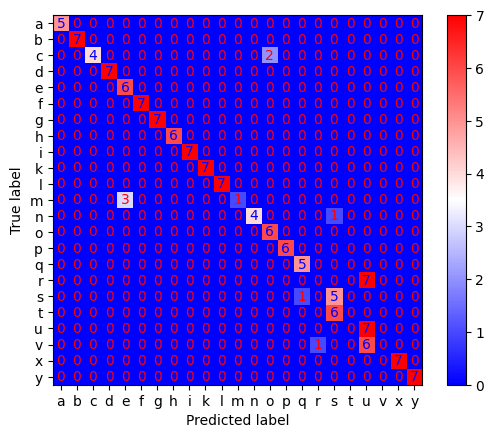

In [39]:
#print(confusion_matrix(y_val, y_val_pred))

matrix = confusion_matrix(y_val, y_val_pred)

display_matrix = ConfusionMatrixDisplay(matrix, display_labels=le.classes_)
display_matrix.plot(cmap='bwr')
plt.show()

There is an issue: images labeled as 't' are labeled as 's' for some reason.

In [43]:
def compare_hands(coords1, coords2):
    x1, y1 = coords1[0::3], coords1[1::3]
    x2, y2 = coords2[0::3], coords2[1::3]

    plt.scatter(x1, y1, label="T")
    plt.scatter(x2, y2, label="S")

    plt.legend()
    plt.gca().invert_yaxis()
    plt.show()

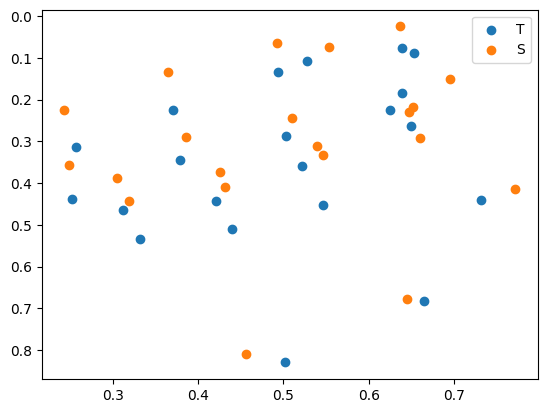

[0.5014830231666565, 0.665078341960907, 0.7318027019500732, 0.6249803900718689, 0.5275397896766663, 0.6499918103218079, 0.6394787430763245, 0.6528056263923645, 0.6392961740493774, 0.5028086304664612, 0.4932028651237488, 0.5214968919754028, 0.5463365912437439, 0.378544420003891, 0.3706502318382263, 0.4211011826992035, 0.43975064158439636, 0.2524893581867218, 0.2570573091506958, 0.3118455410003662, 0.3315283954143524]


TypeError: unsupported operand type(s) for -: 'list' and 'list'

In [ ]:
#get indices of t and s from hand_landmark_label
t_indices = [i for i, label in enumerate(hand_landmark_label) if label == 't']
s_indices = [i for i, label in enumerate(hand_landmark_label) if label == 's']

average_difference = 0.0

# show 5 examples each
for i in range(5):
    t, s = hand_landmark_data[t_indices[i]], hand_landmark_data[s_indices[i]]
    compare_hands(t, s)
    tx, ty = t[0::3], t[1::3]
    sx, sy = s[0::3], s[1::3]
    euclidean_distance = 0.0
    for j in range(len(tx)):
        euclidean_distance += (tx[j]